# Atelier Matplotlib – Visualisation de données de capteurs IoT

Après avoir manipulé les données avec NumPy et Pandas, on les **représente
graphiquement** pour identifier des tendances, comparer les bâtiments et
repérer des anomalies.

## Mise en place
- **Objectif** : importer les bibliothèques et charger le dataset.
- `matplotlib.pyplot` est le module de tracé, importé sous le surnom `plt`.
- On convertit `date_heure` en vrai type date, indispensable pour les courbes
  dans le temps, puis on trie les mesures par ordre chronologique.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mesures_capteurs.csv")

# Conversion de la colonne date en type datetime, puis tri chronologique
df["date_heure"] = pd.to_datetime(df["date_heure"])
df = df.sort_values("date_heure")

df.head()

Matplotlib is building the font cache; this may take a moment.


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
150,M0001,2026-01-05 00:00:00,C001,B001,24.91,54.60,1019.00,222.33,OK
547,M0002,2026-01-05 01:00:00,C002,B001,18.15,51.98,1014.02,165.77,OK
20,M0003,2026-01-05 02:00:00,C003,B001,23.95,56.47,1020.04,215.00,OK
282,M0004,2026-01-05 03:00:00,C004,B002,26.20,76.27,1016.74,191.33,OK
484,M0005,2026-01-05 04:00:00,C005,B002,27.11,55.41,1020.03,227.75,OK


## Partie 1 – Graphique linéaire (Line Plot)

Une courbe relie les points dans l'ordre : idéale pour suivre l'évolution d'une
grandeur **dans le temps**.

### 1. Évolution de la température en fonction du temps
- **Objectif** : tracer une courbe temps → température, avec titre, labels,
  légende et grille.
- **Syntaxe** :
  - `plt.plot(x, y, label=...)` → trace la courbe
  - `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)` → titre et labels
  - `plt.legend()` → affiche la légende, `plt.grid(True)` → affiche la grille

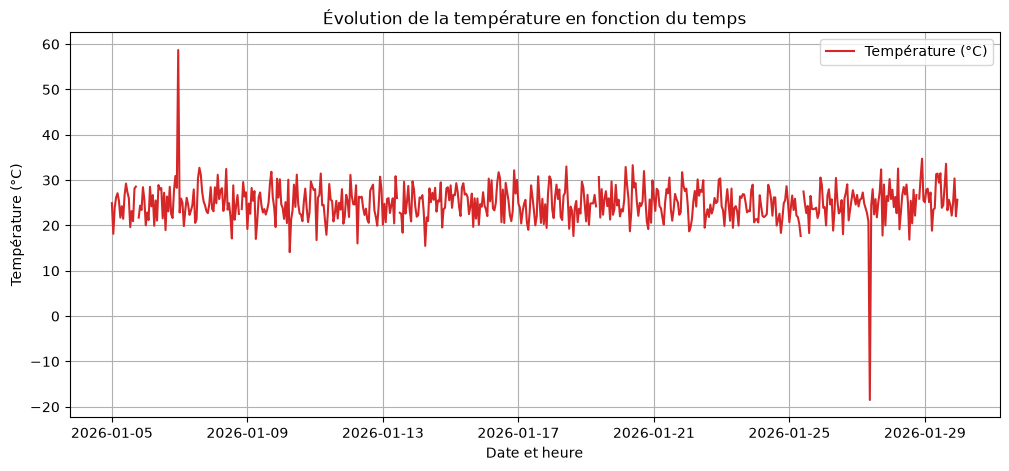

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], color="tab:red", label="Température (°C)")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.show()

### 2. Identifier visuellement les valeurs anormales

Sur la courbe, on repère facilement des **pics isolés** : une température proche
de **58 °C** et une autre proche de **−18 °C**. Physiquement improbables pour un
bâtiment, ce sont des **mesures anormales** (capteurs défaillants ou erreurs de
relevé) — exactement le type de situations que le futur système de ML devra détecter.

## Partie 2 – Diagramme en barres (Bar Chart)

Un diagramme en barres compare des **catégories** entre elles : ici, la
consommation moyenne de chaque bâtiment.

### 1 & 2. Consommation moyenne par bâtiment (barres verticales)
- **Objectif** : calculer la moyenne par bâtiment, puis la représenter.
- **Syntaxe** : `plt.bar(categories, valeurs)`

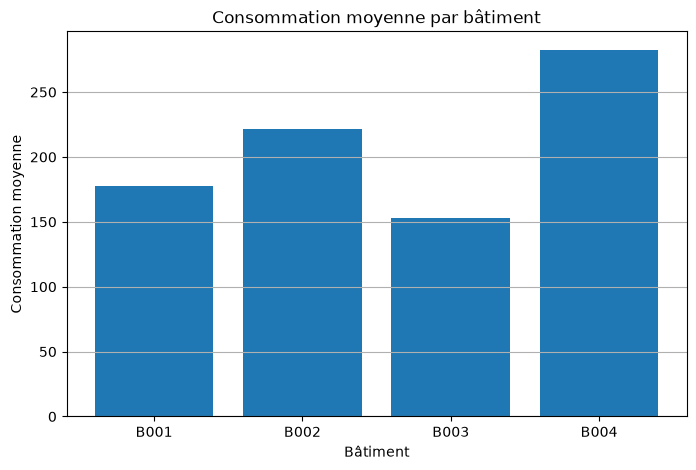

In [3]:
consommation_batiment = df.groupby("batiment")["consommation"].mean()

plt.figure(figsize=(8, 5))
plt.bar(consommation_batiment.index, consommation_batiment.values, color="tab:blue")
plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne")
plt.grid(axis="y")
plt.show()

### 3. Version horizontale
- **Objectif** : mêmes données, barres horizontales.
- **Syntaxe** : `plt.barh(categories, valeurs)`

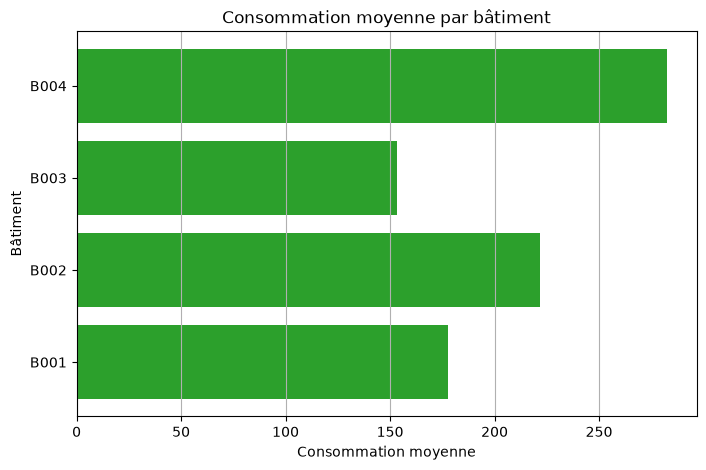

In [4]:
plt.figure(figsize=(8, 5))
plt.barh(consommation_batiment.index, consommation_batiment.values, color="tab:green")
plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Consommation moyenne")
plt.ylabel("Bâtiment")
plt.grid(axis="x")
plt.show()

### 4. Quand le graphique horizontal est-il plus lisible ?

Le graphique **horizontal** est préférable quand :
- les **noms de catégories sont longs** (ils se lisent à l'horizontale sans se chevaucher) ;
- il y a **beaucoup de catégories** (l'empilement vertical reste lisible) ;
- on veut mettre en avant un **classement** (du plus grand au plus petit).

## Partie 3 – Histogramme

Un histogramme montre la **distribution** d'une variable : on découpe la plage
de valeurs en intervalles (les *classes* ou *bins*) et on compte combien de
valeurs tombent dans chacun.

### 1. Distribution des températures (20 classes)
- **Objectif** : visualiser la répartition des températures.
- **Syntaxe** : `plt.hist(donnees, bins=nombre_de_classes)`
- On retire d'abord les valeurs manquantes avec `.dropna()`.
- `plt.grid(axis="y")` n'affiche que les **lignes horizontales** de la grille.

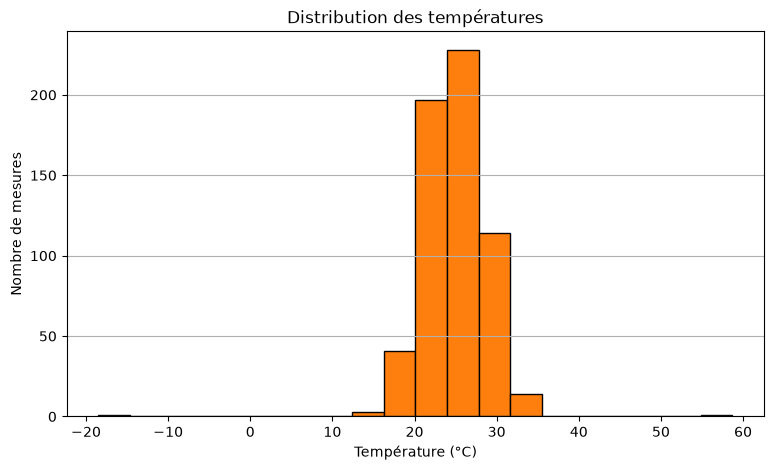

In [5]:
plt.figure(figsize=(9, 5))
plt.hist(df["temperature"].dropna(), bins=20, color="tab:orange", edgecolor="black")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()

### 2. Analyse de la distribution des températures

- **Concentration** : la grande majorité des températures se situe autour de
  **23–26 °C**.
- **Symétrie** : la distribution est globalement **symétrique** (forme en cloche).
- **Valeurs éloignées** : on distingue quelques valeurs très à l'écart, loin du cœur.
- **Valeurs aberrantes** : oui, les extrêmes (~−18 °C et ~58 °C) sont clairement
  aberrants.

### 3. Distribution de la consommation (20, puis 10, puis 30 classes)
- **Objectif** : observer l'effet du nombre de classes sur la lecture.

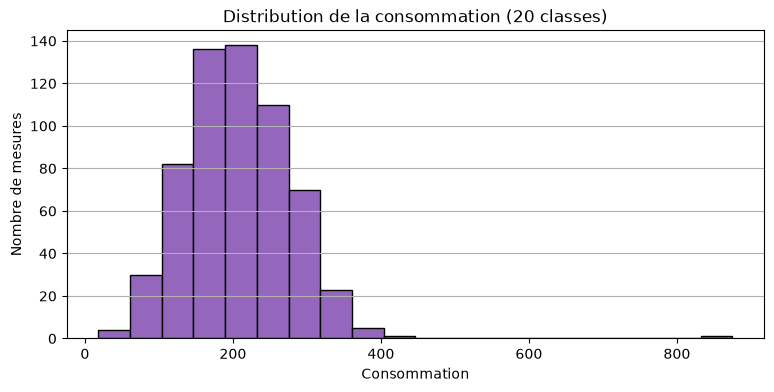

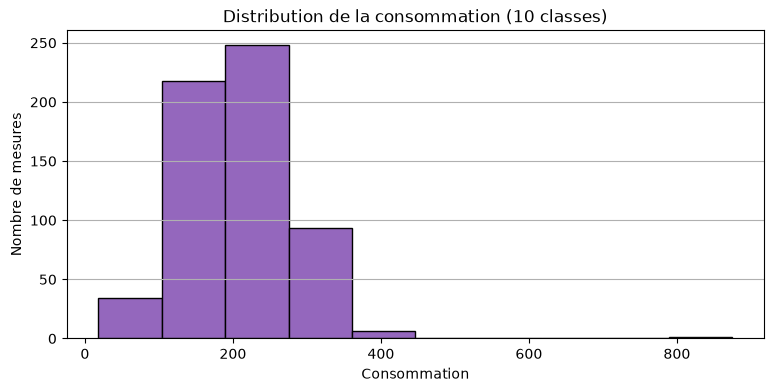

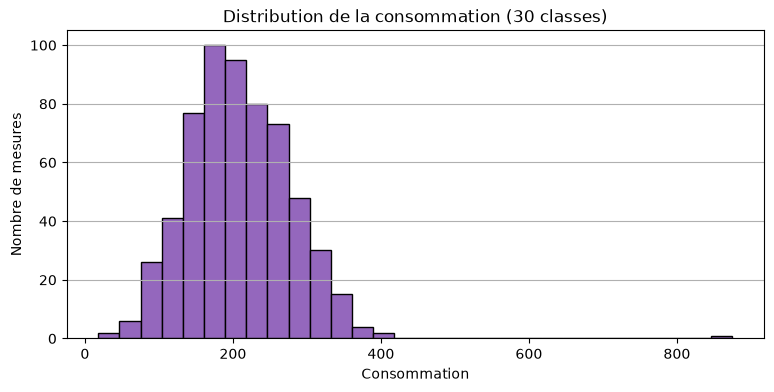

In [6]:
for n in [20, 10, 30]:
    plt.figure(figsize=(9, 4))
    plt.hist(df["consommation"].dropna(), bins=n, color="tab:purple", edgecolor="black")
    plt.title(f"Distribution de la consommation ({n} classes)")
    plt.xlabel("Consommation")
    plt.ylabel("Nombre de mesures")
    plt.grid(axis="y")
    plt.show()

### c. Impact du nombre de classes

- **Peu de classes (10)** : histogramme lisse, vue d'ensemble, mais on perd des détails.
- **Beaucoup de classes (30)** : plus de détails, mais l'histogramme devient
  « bruité » et plus difficile à interpréter.
- Le nombre de classes est donc un **compromis** entre lisibilité globale et finesse.

## Partie 4 – Nuage de points (Scatter Plot)

Un nuage de points affiche chaque mesure comme un point (x, y). Il sert à
repérer une éventuelle **relation entre deux variables**.

### 1 & 2. Température vs consommation
- **Objectif** : chercher une relation entre température et consommation.
- **Syntaxe** : `plt.scatter(x, y)`
- `alpha=0.5` rend les points semi-transparents (utile quand ils se superposent).

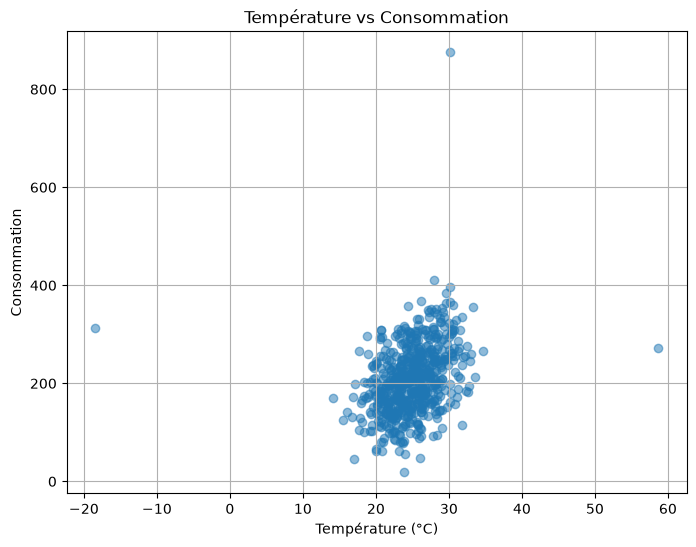

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(df["temperature"], df["consommation"], alpha=0.5, color="tab:blue")
plt.title("Température vs Consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.grid(True)
plt.show()

**Interprétation** : les points sont assez **dispersés**, sans tendance nette
(ni droite montante ni descendante). Il ne semble donc **pas exister de relation
forte** entre la température et la consommation dans ce jeu de données.

## Partie 5 – Diagramme à moustaches (Box Plot)

Le box plot résume une variable : la **boîte** va du 1er au 3e quartile (50 %
des données), la **ligne** au milieu est la médiane, les **moustaches**
s'étendent jusqu'aux valeurs « normales », et les **points isolés** sont les
valeurs extrêmes.

### 1. Box plot de la température
- **Objectif** : visualiser dispersion et valeurs extrêmes de la température.
- **Syntaxe** : `plt.boxplot(donnees)` (on retire d'abord les NaN).

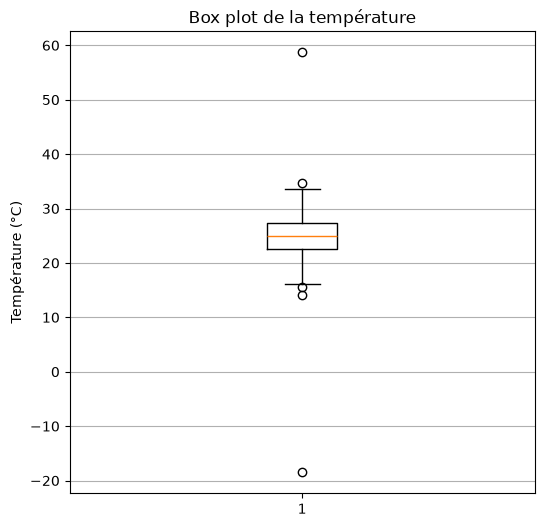

In [8]:
plt.figure(figsize=(6, 6))
plt.boxplot(df["temperature"].dropna())
plt.title("Box plot de la température")
plt.ylabel("Température (°C)")
plt.grid(axis="y")
plt.show()

### 2. Que représentent les points hors des moustaches ?

Ce sont les **valeurs aberrantes (outliers)** : des mesures anormalement
éloignées du reste des données — ici, nos fameuses températures extrêmes.

### 3. Box plot de la consommation

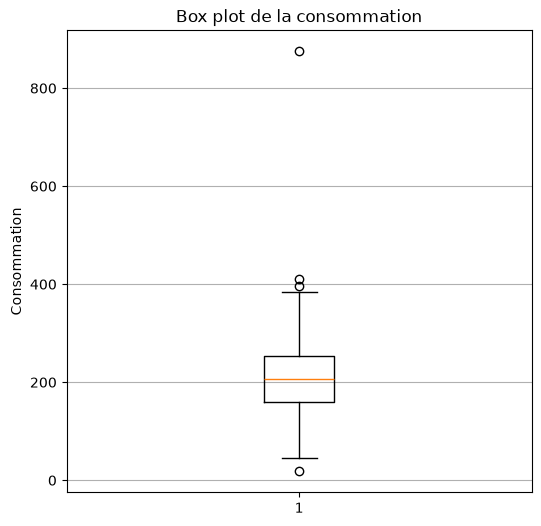

In [9]:
plt.figure(figsize=(6, 6))
plt.boxplot(df["consommation"].dropna())
plt.title("Box plot de la consommation")
plt.ylabel("Consommation")
plt.grid(axis="y")
plt.show()

### 4 & 5. Comparaison des deux box plots

| Critère            | Température        | Consommation                  |
|--------------------|--------------------|-------------------------------|
| Position médiane   | ~24–25 °C          | plus haute, dans son échelle  |
| Taille de la boîte | plutôt **resserrée** | plus **large**              |
| Longueur moustaches| courtes            | plus longues                  |
| Valeurs extrêmes   | quelques-unes      | nombreuses et très hautes     |

**Conclusion** : oui, la **consommation présente davantage de dispersion** que
la température (boîte plus large, moustaches plus longues, extrêmes plus marqués).

## Partie 6 – Diagramme circulaire (Pie Chart)

Le camembert montre la **répartition en proportions** d'une variable
catégorielle : ici, l'état des capteurs.

### 1. Répartition des états
- **Objectif** : proportion de OK, ALERTE, ERREUR.
- **Syntaxe** : `plt.pie(valeurs, labels=..., autopct="%1.1f%%")`
  → `autopct` affiche le pourcentage sur chaque part.

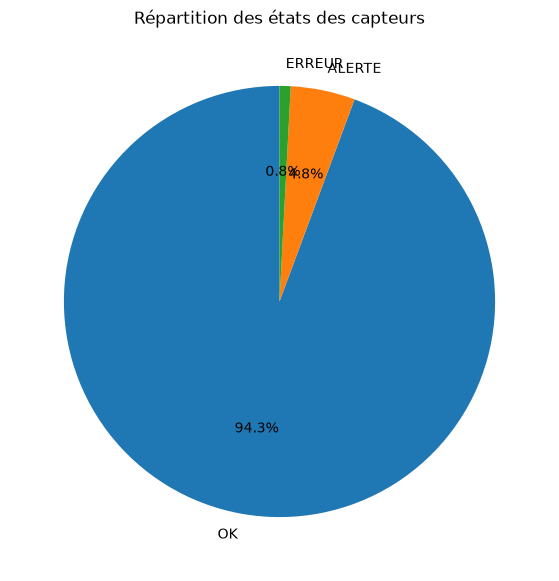

In [10]:
etats = df["etat"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(etats.values, labels=etats.index, autopct="%1.1f%%", startangle=90)
plt.title("Répartition des états des capteurs")
plt.show()

### 2. Interprétation

- La très grande majorité des capteurs sont **OK** (~94 %) : le parc fonctionne
  globalement bien.
- Une petite part est en **ALERTE** (~5 %) : à surveiller.
- Une très faible part est en **ERREUR** (~1 %) : capteurs défaillants à corriger.

## Partie 7 – Évolution de la température par bâtiment

En traçant plusieurs courbes sur un même graphique, on **compare** directement
l'évolution de la température des quatre bâtiments.

- **Objectif** : une courbe par bâtiment, toutes superposées.
- **Syntaxe** : appeler `plt.plot()` une fois par bâtiment (dans une boucle),
  avec un `label` différent, puis un seul `plt.legend()`.

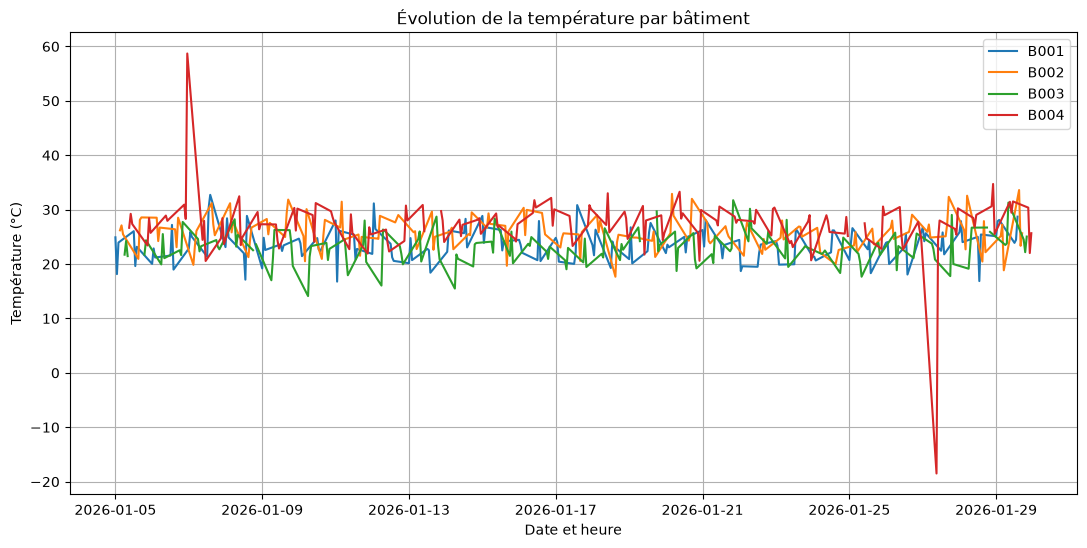

In [11]:
plt.figure(figsize=(13, 6))

for batiment in sorted(df["batiment"].unique()):
    sous_df = df[df["batiment"] == batiment].sort_values("date_heure")
    plt.plot(sous_df["date_heure"], sous_df["temperature"], label=batiment)

plt.title("Évolution de la température par bâtiment")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.show()

## Partie 8 – Sauvegarde des graphiques

On sauvegarde un graphique dans un fichier avec `plt.savefig()`. **Important** :
il faut appeler `savefig()` **avant** `plt.show()` (sinon le fichier est vide).
Le même graphique peut être exporté en **PNG** (image) et en **PDF** (vectoriel).

### 1 & 2. Exporter la courbe de température en PNG et PDF
- **Syntaxe** : `plt.savefig("chemin.png", dpi=300, bbox_inches="tight")`
  - `dpi=300` = bonne résolution ; `bbox_inches="tight"` = rogne les marges inutiles.

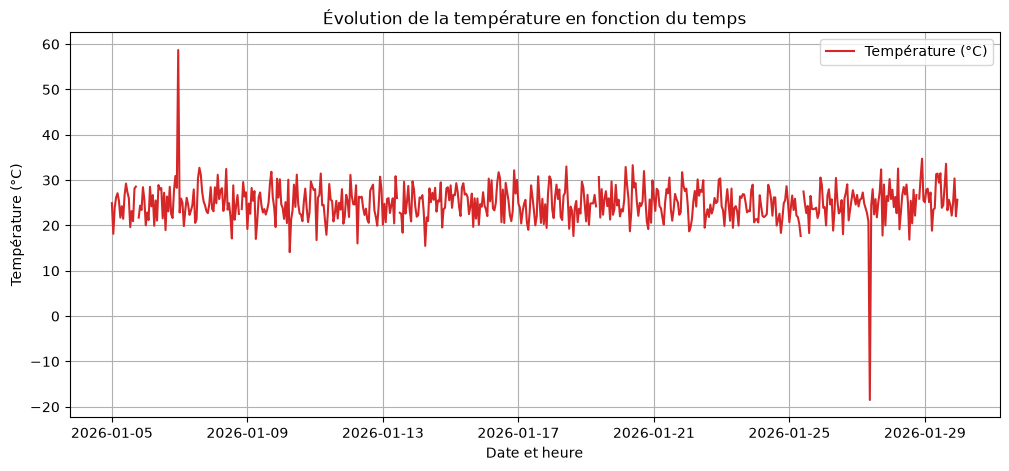

Graphiques sauvegardés dans le dossier exports/ ✅


In [12]:
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], color="tab:red", label="Température (°C)")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)

# Sauvegardes AVANT le show
plt.savefig("../exports/temperature.png", dpi=300, bbox_inches="tight")
plt.savefig("../exports/temperature.pdf", bbox_inches="tight")

plt.show()
print("Graphiques sauvegardés dans le dossier exports/ ✅")

## Partie 9 – Bonus : mise en évidence des anomalies sur la courbe

On superpose à la courbe de température les **points anormaux** (température
< 0 °C ou > 45 °C) en rouge, pour les repérer d'un coup d'œil.

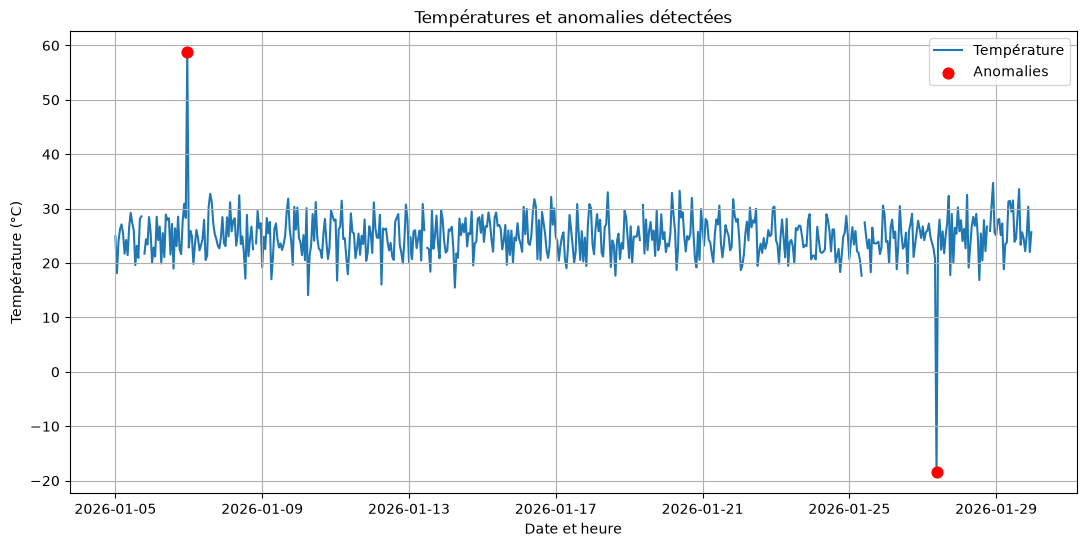

Nombre de mesures anormales : 2


In [13]:
anomalies = df[(df["temperature"] < 0) | (df["temperature"] > 45)]

plt.figure(figsize=(13, 6))
plt.plot(df["date_heure"], df["temperature"], color="tab:blue", label="Température", zorder=1)
plt.scatter(anomalies["date_heure"], anomalies["temperature"],
            color="red", s=60, label="Anomalies", zorder=2)
plt.title("Températures et anomalies détectées")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.show()

print("Nombre de mesures anormales :", len(anomalies))